# Experiment: demand prediction at different time horizons

**Experimental notebook.**

The production system predicts bike demand for the **next hour** (h+1). This notebook
measures, with the project's real data and features, what happens to accuracy when we want to
predict **further ahead** (h+2, h+3, ..., h+24) — to decide, with evidence, whether it's worth
reframing the problem later on.

We compare three things as a function of horizon:

1. **Direct** — a dedicated model per horizon, using only the features available at that
   distance (short lags stop being available as we look further ahead).
2. **Recursive** — reuse the h+1 model, chaining it: feed its own predictions back as if they
   were the real values. The cheapest path to implement (no retraining needed).
3. **Seasonal-naive baseline** — predict "the same as this hour, one week ago"
   (`cnt_lag_168`). The minimum bar: if the model can't beat this, it adds no value.

> **Methodological note:** we use the **real** weather of the target hour (same as production
> training). In real serving, future weather is unknown and gets approximated by persistence —
> that's an additional, separate degradation this notebook does not measure.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from bike_sharing.features.build_features import build_lag_features, build_calendar_features
from bike_sharing.utils.datetime_utils import reconstruct_datetime
from bike_sharing.models.train import FEATURES, compute_metrics

# Config identical to production (configs/features + configs/model/best_params)
LAGS = [1, 2, 3, 8, 24, 48, 72, 168]
ROLLING = [24, 168]
DROP_COLS = ["atemp", "cnt_lag_9", "cnt_lag_10", "season", "mnth_sin", "mnth_cos",
             "workingday", "holiday", "windspeed", "yr"]
PARAMS = dict(
    colsample_bytree=0.8698150989301724, learning_rate=0.025387866446568996,
    max_depth=9, min_child_samples=21, n_estimators=642, num_leaves=278,
    reg_alpha=4.683619163491815e-08, reg_lambda=0.2599638533448982,
    subsample=0.6581158719444499,
    objective="regression", metric="rmse", verbosity=-1, n_jobs=-1,
)

# Calendar/weather features = everything that isn't a lag or a rolling mean (always available)
CAL_COLS = [f for f in FEATURES if not f.startswith("cnt_lag_") and not f.startswith("cnt_rolling_mean_")]
HORIZONS = [1, 2, 3, 6, 12, 24]
print("Calendar/weather features:", CAL_COLS)

/Users/robertogarces/miniforge3/envs/bike-sharing-forecast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Calendar/weather features: ['hr_sin', 'hr_cos', 'hr_workday', 'hr_weekend', 'hr_x_season', 'is_rush_hour', 'days_since_start', 'temp', 'hum', 'weathersit']


## 2. Load data and build features

We reuse the project's real functions (`build_lag_features`, `build_calendar_features`) so the
experiment is faithful to the training pipeline, not a reimplementation.

In [2]:
df = pd.read_csv("../data/raw/hour_past.csv")
df = reconstruct_datetime(df)
df = df.sort_values("datetime").reset_index(drop=True)

# Build features over the full series (same as build_features.py)
feat = build_lag_features(df, lags=LAGS, rolling_windows=ROLLING)
min_date = feat["dteday"].min()
feat = build_calendar_features(feat, DROP_COLS, min_date)
feat["log_registered"] = np.log1p(feat["registered"])
feat["log_casual"] = np.log1p(feat["casual"])

print(f"{len(df):,} rows | {df['datetime'].min()} -> {df['datetime'].max()}")
assert all(f in feat.columns for f in FEATURES), "Missing a feature"


16,313 rows | 2024-08-17 00:00:00 -> 2026-07-04 10:00:00


In [3]:
# Temporal 80/20 split (same criterion as production)
cutoff = feat["dteday"].quantile(0.8)
train = feat[feat["dteday"] <= cutoff].dropna(subset=FEATURES + ["log_registered", "log_casual"]).copy()
test = feat[feat["dteday"] > cutoff].dropna(subset=FEATURES).copy()
print(f"train: {len(train):,} | test: {len(test):,}")


def train_pair(tr, cols):
    '''Train the (registered, casual) model pair in log-space, same as production.'''
    m_reg = lgb.LGBMRegressor(**PARAMS).fit(tr[cols], tr["log_registered"])
    m_cas = lgb.LGBMRegressor(**PARAMS).fit(tr[cols], tr["log_casual"])
    return m_reg, m_cas


def predict_pair(m_reg, m_cas, X):
    '''expm1 of each model, sum, clip at 0 — identical to evaluate/predict.'''
    return np.clip(np.expm1(m_reg.predict(X)) + np.expm1(m_cas.predict(X)), 0, None)


def cols_for_horizon(k):
    '''
    Features available when predicting k hours ahead:
    - calendar/weather: always.
    - lags: only offsets >= k (shorter ones point to hours that haven't happened yet).
    - rolling means: use shift(1), i.e. the previous hour -> only available at h+1.
    '''
    if k == 1:
        return FEATURES
    return CAL_COLS + [f"cnt_lag_{L}" for L in LAGS if L >= k]

train: 12,883 | test: 3,262


## 3. Experiment 1 — does the model beat the trivial baseline? (h+1)

Before looking at horizons, the base question: at 1 hour, does the ML model add anything over
"predict the same as this hour last week"?

In [4]:
# Direct h+1 model (all features)
m_reg, m_cas = train_pair(train, FEATURES)
pred_h1 = predict_pair(m_reg, m_cas, test[FEATURES])
rmse_h1 = compute_metrics(test["cnt"].values, pred_h1)["rmse"]

# Seasonal-naive baseline: cnt(t) ~= cnt(t-168)
mask = test["cnt_lag_168"].notna()
rmse_naive = compute_metrics(test.loc[mask, "cnt"].values, test.loc[mask, "cnt_lag_168"].values)["rmse"]

print(f"Model h+1         RMSE = {rmse_h1:.2f}")
print(f"Seasonal-naive    RMSE = {rmse_naive:.2f}")
print(f"Model improvement over baseline: {100 * (1 - rmse_h1 / rmse_naive):.1f}%")

Model h+1         RMSE = 55.30
Seasonal-naive    RMSE = 130.89
Model improvement over baseline: 57.8%


## 4. Experiment 2 — Direct multi-horizon

For each horizon, we train a **dedicated** model that only sees the features available at that
distance. This marks the "ceiling" reachable per horizon if we were willing to retrain a model
for each one.

In [5]:
rmse_direct = {}
for k in HORIZONS:
    cols = cols_for_horizon(k)
    mr_k, mc_k = train_pair(train, cols)
    pred_k = predict_pair(mr_k, mc_k, test[cols])
    rmse_direct[k] = compute_metrics(test["cnt"].values, pred_k)["rmse"]
    print(f"h+{k:2d}  ({len(cols):2d} features)  RMSE = {rmse_direct[k]:.2f}")

h+ 1  (20 features)  RMSE = 55.30


h+ 2  (17 features)  RMSE = 73.68


h+ 3  (16 features)  RMSE = 79.59


h+ 6  (15 features)  RMSE = 85.58


h+12  (14 features)  RMSE = 85.84


h+24  (14 features)  RMSE = 85.84


## 5. Experiment 3 — Recursive

We reuse the (already trained) h+1 model and chain it: predict h+1, use that prediction as if
it were the real value, predict h+2, and so on. Nothing gets retrained. The cost is that errors
accumulate step by step.

In [6]:
H = max(HORIZONS)
cnt_full = df["cnt"].to_numpy(dtype=float)

# Calendar/weather doesn't depend on cnt -> precompute once for the whole series
cal_all = build_calendar_features(df.copy(), DROP_COLS, min_date)
cal_mat = cal_all[CAL_COLS].to_numpy(dtype=float)


def feature_row(work_cnt, i):
    '''Feature vector for hour i using work_cnt (with predictions fed back in).'''
    row = {c: cal_mat[i, j] for j, c in enumerate(CAL_COLS)}
    for L in LAGS:
        row[f"cnt_lag_{L}"] = work_cnt[i - L]
    for W in ROLLING:
        row[f"cnt_rolling_mean_{W}"] = work_cnt[i - W:i].mean()
    return row


# Sample origins from the test set for the rollout
test_idx = test.index.to_numpy()
valid = test_idx[(test_idx - H > 0) & (test_idx + H < len(df))]
rng = np.random.default_rng(0)
origins = rng.choice(valid, size=min(300, len(valid)), replace=False)

sq_err = {h: [] for h in range(1, H + 1)}
for o in origins:
    work = cnt_full.copy()          # starts from the real actuals up to the origin
    for h in range(1, H + 1):
        i = o + h
        X = pd.DataFrame([feature_row(work, i)])[FEATURES]
        yhat = predict_pair(m_reg, m_cas, X)[0]
        sq_err[h].append((cnt_full[i] - yhat) ** 2)
        work[i] = yhat              # feed the prediction back for the next step

rmse_recursive = {h: float(np.sqrt(np.mean(v))) for h, v in sq_err.items()}
print(f"{len(origins)} origins, {H}-hour rollout")
for k in HORIZONS:
    print(f"h+{k:2d}  RMSE = {rmse_recursive[k]:.2f}")

300 origins, 24-hour rollout
h+ 1  RMSE = 56.49
h+ 2  RMSE = 67.10
h+ 3  RMSE = 69.23
h+ 6  RMSE = 70.66
h+12  RMSE = 74.91
h+24  RMSE = 77.98


## 6. Final comparison

,direct,recursive,seasonal_naive
horizon,,,
1,55.30,56.49,130.89
2,73.68,67.10,130.89
3,79.59,69.23,130.89
6,85.58,70.66,130.89
12,85.84,74.91,130.89
24,85.84,77.98,130.89


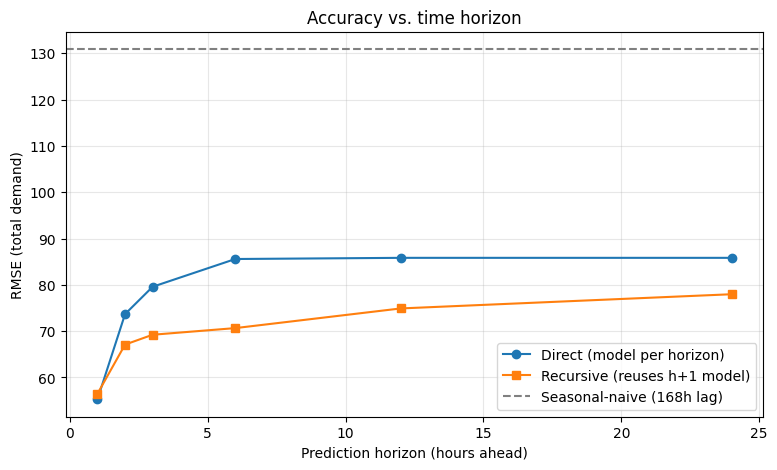

In [7]:
table = pd.DataFrame({
    "horizon": HORIZONS,
    "direct": [rmse_direct[k] for k in HORIZONS],
    "recursive": [rmse_recursive[k] for k in HORIZONS],
    "seasonal_naive": [rmse_naive] * len(HORIZONS),
}).set_index("horizon")
display(table.round(2))

plt.figure(figsize=(9, 5))
plt.plot(HORIZONS, table["direct"], "o-", label="Direct (model per horizon)")
plt.plot(HORIZONS, table["recursive"], "s-", label="Recursive (reuses h+1 model)")
plt.axhline(rmse_naive, ls="--", color="gray", label="Seasonal-naive (168h lag)")
plt.xlabel("Prediction horizon (hours ahead)")
plt.ylabel("RMSE (total demand)")
plt.title("Accuracy vs. time horizon")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Reading / expectations

When running this, pay attention especially to:

- **How much the model beats seasonal-naive at h+1** (Experiment 1). This is what justifies
  the whole ML apparatus — if the improvement were marginal, the project's value would be in
  the MLOps machinery, not the model.
- **How fast RMSE rises as the horizon grows**, and at which horizon the model stops beating
  the flat baseline. That crossover marks the useful limit of the approach.
- **Direct vs. recursive**: direct loses the short lags and rolling means (that's why its
  feature set shrinks with the horizon); recursive keeps them by feeding predictions back, at
  the cost of accumulating error. Which one wins in each range is empirical — this notebook
  answers it with real data.

All of this feeds the later decision of whether to reframe the problem as multi-horizon.
Remember the weather here is the real weather of the target hour; in production it would be
persisted or forecast — an additional degradation to consider separately.